# Predicting NBA Draft Tier from NCAA Production

### An ordinal machine-learning study of college production, efficiency, and draft outcomes

This notebook predicts an ordered NBA draft outcome from the three supplied datasets:

- `ncaa-stats-complete.xlsx` — traditional NCAA player statistics,
- `ncaa-advanced-stats-complete.xlsx` — advanced NCAA player statistics,
- `nba-past-drafts.xlsx` — historical NBA draft outcomes.

The target is deliberately **coarser than exact pick number**:

1. **Top 5**
2. **Lottery (6–14)**
3. **Rest of 1st (15–30)**
4. **2nd Round**
5. **Undrafted**

The classes are ordered. A Top-5 prospect predicted as Lottery is a smaller mistake than a Top-5 prospect predicted as Undrafted, so the evaluation and modeling strategy explicitly respect ordinal distance.

## 1. Project goals

This is a portfolio-grade basketball analytics project built to the same approximate scope as the NFL draft-round notebook.

The workflow demonstrates:

- multi-table NCAA + NBA draft data integration,
- schema, duplicate, and missingness auditing,
- conservative player-name matching without shared IDs,
- construction of an undrafted comparison group,
- final-season and career-average NCAA features,
- leakage-aware chronological validation,
- class-imbalance handling,
- linear, random-forest, and boosted-tree baselines,
- a cumulative ordinal XGBoost model,
- Bayesian hyperparameter optimization with Optuna TPE,
- probability ensembling,
- uncertainty diagnostics,
- feature-set ablation,
- permutation importance,
- draft-tier and year-specific error analysis,
- reusable model and prediction exports.

## 2. Validation design

Random train/test splits are inappropriate for a historical draft study because they let future draft classes influence training.

This notebook uses:

- **Training:** draft cohorts through 2018
- **Validation:** 2019–2021
- **Untouched test:** 2022–2023
- **Bayesian optimization:** expanding-window validation inside the training period

The final test set is not used for hyperparameter selection or ensemble-weight selection.

## 3. Optional dependency installation

The notebook uses common data-science packages plus `xgboost` and `optuna`. The following cell installs only missing packages.

In [1]:
import importlib.util
import subprocess
import sys

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
    "optuna": "optuna",
    "openpyxl": "openpyxl",
    "joblib": "joblib",
}

missing = [pip_name for module, pip_name in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed.")

All required packages are already installed.


In [2]:
from pathlib import Path
import math
import os
import re
import unicodedata
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42
N_JOBS = max(1, min(4, os.cpu_count() or 1))
np.random.seed(RANDOM_STATE)

CLASS_NAMES = [
    "Top 5",
    "Lottery (6-14)",
    "Rest of 1st (15-30)",
    "2nd Round",
    "Undrafted",
]
CLASS_SHORT = ["Top 5", "6-14", "15-30", "R2", "UD"]
N_CLASSES = len(CLASS_NAMES)
CLASS_INDEX = np.arange(N_CLASSES)

TRAIN_END = 2018
VALID_YEARS = [2019, 2020, 2021]
TEST_YEARS = [2022, 2023]

# This removes extremely small NCAA samples from the prospect universe.
# It is not a claim about NBA eligibility; it is a modeling-quality filter.
MIN_CAREER_GAMES = 10
# Increase for a longer search. 40 mirrors a substantial portfolio run while
# still being practical on a laptop.
N_TRIALS = 40

# Part I — Source data and audit

## 4. Load the three source files

The loader checks both the notebook's current directory and `/mnt/data`, so the same notebook can be run locally or in this environment.

In [3]:
def resolve_file(filename):
    candidates = [Path.cwd() / filename, Path("/mnt/data") / filename]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}. Checked: {candidates}")

BASIC_PATH = resolve_file("ncaa-stats-complete.xlsx")
ADV_PATH = resolve_file("ncaa-advanced-stats-complete.xlsx")
DRAFT_PATH = resolve_file("nba-past-drafts.xlsx")

print("Basic NCAA:", BASIC_PATH)
print("Advanced NCAA:", ADV_PATH)
print("NBA drafts:", DRAFT_PATH)

Basic NCAA: /Users/svlahos/Downloads/ncaa-stats-complete.xlsx
Advanced NCAA: /Users/svlahos/Downloads/ncaa-advanced-stats-complete.xlsx
NBA drafts: /Users/svlahos/Downloads/nba-past-drafts.xlsx


In [4]:
basic_raw = pd.read_excel(BASIC_PATH)
advanced_raw = pd.read_excel(ADV_PATH)
draft_raw = pd.read_excel(DRAFT_PATH)

print("basic_raw:", basic_raw.shape)
print("advanced_raw:", advanced_raw.shape)
print("draft_raw:", draft_raw.shape)

display(basic_raw.head())
display(advanced_raw.head())
display(draft_raw.head())

basic_raw: (15947, 23)
advanced_raw: (15947, 21)
draft_raw: (1190, 4)


,player,cls,year,gp,mpg,ppg,fgm,fga,fg%,3pm,3pa,3p%,ftm,fta,ft%,orb,drb,rpg,apg,spg,bpg,tov,pf
0,Kee-Kee Clark,Fr,2003,29,38.200,24.900,8.000,20.100,0.396,3.800,9.600,0.392,5.200,6.100,0.853,0.800,2.400,3.300,4.200,1.400,0.200,4.000,1.900
1,Carmelo Anthony,Fr,2003,35,36.400,22.200,7.900,17.500,0.453,1.600,4.700,0.337,4.800,6.800,0.706,2.900,6.900,9.700,2.200,1.500,0.900,2.200,2.200
2,Darshan Luckey,Fr,2003,28,37.500,21.600,7.200,18.800,0.383,1.600,5.900,0.280,5.600,7.200,0.777,0.800,4.400,5.100,1.600,1.700,0.300,4.100,2.300
3,Craig Smith,Fr,2003,31,31.900,19.900,7.800,12.900,0.603,0.100,0.500,0.200,4.300,6.300,0.677,3.200,4.700,7.900,1.300,0.900,0.900,2.400,3.400
4,Ike Diogu,Fr,2003,32,32.200,19.000,6.600,10.800,0.609,0.300,0.800,0.375,5.600,7.700,0.735,3.100,4.800,7.800,0.800,0.300,1.000,2.800,2.900


,player,cls,year,TS%,eFG%,totalS%,orb%,drb%,trb%,ast%,tov%,stl%,blk%,usg%,ppr,pps,ORtg,DRtg,eDiff,FIC,PER
0,Michael Haddix,Fr,2003,0.561,0.521,120.800,7.900,11.100,9.500,4.100,9.300,1.600,3.600,24.000,-4.100,1.400,119.800,108.400,11.400,310.800,26.300
1,Craig Smith,Fr,2003,0.626,0.606,147.900,12.500,17.800,15.200,9.300,13.100,1.500,2.800,27.400,-4.500,1.500,121.700,104.900,16.800,422.400,26.000
2,Carmelo Anthony,Fr,2003,0.537,0.498,149.600,9.500,19.500,14.800,11.900,9.600,2.200,2.300,29.300,-1.900,1.300,116.800,92.500,24.300,554.300,25.000
3,Chris Bosh,Fr,2003,0.633,0.596,175.800,11.600,22.300,16.900,7.900,15.800,1.700,6.800,22.400,-4.600,1.600,120.700,93.500,27.200,453.000,24.700
4,Kee-Kee Clark,Fr,2003,0.541,0.490,164.100,1.400,4.700,3.000,23.700,14.700,2.400,0.500,32.500,-3.400,1.200,109.100,121.600,-12.500,321.100,24.500


,player,year,draft_pos,drafted
0,Dwight Howard,2004,1,first round
1,Emeka Okafor,2004,2,first round
2,Ben Gordon,2004,3,first round
3,Shaun Livingston,2004,4,first round
4,Devin Harris,2004,5,first round


## 5. Schema, missingness, and duplicate audit

Before modeling, inspect each source rather than assuming row uniqueness or perfect alignment between the two NCAA tables.

In [5]:
def audit_table(df, name):
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Duplicate full rows:", df.duplicated().sum())
    display(pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
        "unique": df.nunique(dropna=True),
    }).sort_values("missing_pct", ascending=False))

for name, df in {
    "Traditional NCAA": basic_raw,
    "Advanced NCAA": advanced_raw,
    "NBA Draft": draft_raw,
}.items():
    audit_table(df, name)


Traditional NCAA
Shape: (15947, 23)
Duplicate full rows: 0


,dtype,missing,missing_pct,unique
player,object,0,0.000,11584
ftm,float64,0,0.000,86
tov,float64,0,0.000,51
bpg,float64,0,0.000,47
spg,float64,0,0.000,38
apg,float64,0,0.000,87
rpg,float64,0,0.000,130
drb,float64,0,0.000,96
orb,float64,0,0.000,57
ft%,float64,0,0.000,622



Advanced NCAA
Shape: (15947, 21)
Duplicate full rows: 0


,dtype,missing,missing_pct,unique
player,object,0,0.000,11688
stl%,float64,0,0.000,76
FIC,float64,0,0.000,3692
eDiff,float64,0,0.000,841
DRtg,float64,0,0.000,446
ORtg,float64,0,0.000,711
pps,float64,0,0.000,16
ppr,float64,0,0.000,194
usg%,float64,0,0.000,321
blk%,float64,0,0.000,167



NBA Draft
Shape: (1190, 4)
Duplicate full rows: 0


,dtype,missing,missing_pct,unique
player,object,0,0.000,1188
year,int64,0,0.000,20
draft_pos,int64,0,0.000,30
drafted,object,0,0.000,2


In [6]:
coverage = pd.DataFrame({
    "dataset": ["Traditional NCAA", "Advanced NCAA", "NBA Draft"],
    "min_year": [basic_raw["year"].min(), advanced_raw["year"].min(), draft_raw["year"].min()],
    "max_year": [basic_raw["year"].max(), advanced_raw["year"].max(), draft_raw["year"].max()],
    "rows": [len(basic_raw), len(advanced_raw), len(draft_raw)],
    "unique_players": [basic_raw["player"].nunique(), advanced_raw["player"].nunique(), draft_raw["player"].nunique()],
})
coverage

,dataset,min_year,max_year,rows,unique_players
0,Traditional NCAA,2003,2024,15947,11584
1,Advanced NCAA,2003,2024,15947,11688
2,NBA Draft,2004,2023,1190,1188


# Part II — Cleaning and entity resolution

## 6. Standardize column names and player-name keys

There is no stable player ID shared across the files, so the notebook performs conservative name normalization.

Two keys are created:

- a **strict key** that preserves suffixes such as Jr./III,
- a **loose key** used only as a fallback when strict matching fails.

Temporal plausibility is then required: a player's NCAA career must overlap the six seasons before the draft year. This reduces false matches between different people with the same name.

In [7]:
COLUMN_MAP = {
    "fg%": "fg_pct",
    "3pm": "three_pm",
    "3pa": "three_pa",
    "3p%": "three_pct",
    "ft%": "ft_pct",
    "TS%": "ts_pct",
    "eFG%": "efg_pct",
    "totalS%": "total_s_pct",
    "orb%": "orb_pct",
    "drb%": "drb_pct",
    "trb%": "trb_pct",
    "ast%": "ast_pct",
    "tov%": "tov_pct",
    "stl%": "stl_pct",
    "blk%": "blk_pct",
    "usg%": "usg_pct",
    "ORtg": "ortg",
    "DRtg": "drtg",
    "eDiff": "ediff",
    "FIC": "fic",
    "PER": "per",
}

def standardize_columns(df):
    return df.rename(columns={c: COLUMN_MAP.get(c, c.lower()) for c in df.columns})

def normalize_name(name, drop_suffix=False):
    if pd.isna(name):
        return ""
    text = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode().lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    if drop_suffix:
        tokens = text.split()
        while tokens and tokens[-1] in {"jr", "sr", "ii", "iii", "iv", "v"}:
            tokens = tokens[:-1]
        text = " ".join(tokens)
    return text

basic = standardize_columns(basic_raw.copy())
advanced = standardize_columns(advanced_raw.copy())
draft = standardize_columns(draft_raw.copy())

for df in (basic, advanced, draft):
    df["player_key"] = df["player"].map(normalize_name)
    df["player_key_loose"] = df["player"].map(lambda x: normalize_name(x, drop_suffix=True))

## 7. Collapse duplicate player-season rows inside each NCAA source

If a player-season appears more than once, numeric values are averaged and descriptive fields are retained. This prevents accidental row multiplication during the traditional/advanced merge.

In [8]:
def collapse_player_seasons(df):
    id_cols = ["player", "cls", "player_key", "player_key_loose", "year"]
    numeric_cols = [c for c in df.columns if c not in id_cols]
    agg = {c: "mean" for c in numeric_cols}
    agg.update({"player": "first", "cls": "last", "player_key_loose": "first"})
    return (
        df.groupby(["player_key", "year"], as_index=False)
        .agg(agg)
        .sort_values(["player_key", "year"])
        .reset_index(drop=True)
    )

basic_season = collapse_player_seasons(basic)
advanced_season = collapse_player_seasons(advanced)

print("Traditional collapsed:", basic_season.shape)
print("Advanced collapsed:", advanced_season.shape)

Traditional collapsed: (15920, 25)
Advanced collapsed: (15926, 23)


In [9]:
seasons = basic_season.merge(
    advanced_season,
    on=["player_key", "year"],
    how="outer",
    suffixes=("_basic", "_advanced"),
    indicator=True,
)

seasons["player"] = seasons["player_basic"].combine_first(seasons["player_advanced"])
seasons["cls"] = seasons["cls_basic"].combine_first(seasons["cls_advanced"])
seasons["player_key_loose"] = seasons["player_key_loose_basic"].combine_first(
    seasons["player_key_loose_advanced"]
)

seasons = seasons.drop(columns=[
    "player_basic", "player_advanced", "cls_basic", "cls_advanced",
    "player_key_loose_basic", "player_key_loose_advanced",
])

source_overlap = seasons["_merge"].value_counts().rename_axis("source_status").to_frame("rows")
source_overlap["pct"] = source_overlap["rows"] / source_overlap["rows"].sum()
display(source_overlap)

seasons = seasons.drop(columns="_merge").sort_values(["player_key", "year"]).reset_index(drop=True)
print("Combined player-season table:", seasons.shape)

,rows,pct
source_status,,
right_only,10428,0.396
left_only,10422,0.396
both,5498,0.209


Combined player-season table: (26348, 43)


## 8. Split same-name careers when they are far apart in time

A name can belong to more than one college player across two decades. Without a player ID, a practical safeguard is to start a new career cluster whenever the same normalized name reappears after a gap of more than five years.

In [10]:
seasons["career_cluster"] = (
    seasons.groupby("player_key")["year"]
    .diff()
    .fillna(0)
    .gt(5)
    .groupby(seasons["player_key"])
    .cumsum()
    .astype(int)
)
seasons["career_id"] = seasons["player_key"] + "__" + seasons["career_cluster"].astype(str)

career_meta = (
    seasons.groupby("career_id")
    .agg(
        player=("player", "first"),
        player_key=("player_key", "first"),
        player_key_loose=("player_key_loose", "first"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        observed_seasons=("year", "nunique"),
    )
    .reset_index()
)

print("Distinct career clusters:", len(career_meta))
display(career_meta.head())

Distinct career clusters: 16358


,career_id,player,player_key,player_key_loose,first_year,last_year,observed_seasons
0,a c curry__0,A.C. Curry,a c curry,a c curry,2023,2023,1
1,a c reid__0,A.C. Reid,a c reid,a c reid,2017,2017,1
2,a d vassallo__0,A.D. Vassallo,a d vassallo,a d vassallo,2007,2009,2
3,a j abrams__0,A.J. Abrams,a j abrams,a j abrams,2006,2009,4
4,a j astroth__0,A.J. Astroth,a j astroth,a j astroth,2015,2017,2


## 9. Match historical draftees to plausible NCAA careers

The draft table includes players who never played NCAA basketball, so not every draft record should match.

Matching rules:

1. strict normalized-name match first,
2. NCAA career must touch the six-year window ending in the draft year,
3. among multiple candidates, prefer the career whose final observed season is closest to the draft,
4. only if strict matching fails, try the suffix-insensitive key.

In [11]:
def best_temporal_matches(draft_df, careers, left_key, right_key, exclude_draft_idx=None):
    d = draft_df.reset_index(names="draft_idx").copy()
    if exclude_draft_idx is not None:
        d = d[~d["draft_idx"].isin(exclude_draft_idx)].copy()

    candidates = d.merge(
        careers,
        left_on=left_key,
        right_on=right_key,
        how="left",
        suffixes=("_draft", "_career"),
    )
    candidates = candidates[
        (candidates["first_year"] <= candidates["year"]) &
        (candidates["last_year"] >= candidates["year"] - 6)
    ].copy()

    candidates["temporal_gap"] = np.where(
        candidates["last_year"] <= candidates["year"],
        candidates["year"] - candidates["last_year"],
        100 + candidates["last_year"] - candidates["year"],
    )
    return (
        candidates.sort_values(["draft_idx", "temporal_gap", "last_year"])
        .drop_duplicates("draft_idx")
        .copy()
    )

strict_matches = best_temporal_matches(draft, career_meta, "player_key", "player_key")
strict_matches["match_method"] = "strict"

loose_matches = best_temporal_matches(
    draft,
    career_meta,
    "player_key_loose",
    "player_key_loose",
    exclude_draft_idx=set(strict_matches["draft_idx"]),
)
loose_matches["match_method"] = "loose"

match_cols = [
    "draft_idx", "career_id", "match_method", "temporal_gap",
    "player_draft", "year", "draft_pos", "drafted",
]
draft_matches = pd.concat([
    strict_matches[match_cols],
    loose_matches[match_cols],
], ignore_index=True)

# A single NCAA career should map to at most one historical draft event.
draft_matches = (
    draft_matches.sort_values(["career_id", "temporal_gap", "year"])
    .drop_duplicates("career_id")
    .reset_index(drop=True)
)

print(f"Matched NCAA careers to {len(draft_matches):,} of {len(draft):,} draft records")
print("Match methods:", draft_matches["match_method"].value_counts().to_dict())
display(draft_matches.head(10))

Matched NCAA careers to 796 of 1,190 draft records
Match methods: {'strict': 794, 'loose': 2}


,draft_idx,career_id,match_method,temporal_gap,player_draft,year,draft_pos,drafted
0,1093,a j griffin jr__0,strict,0.000,"A.J. Griffin, Jr.",2022,16,first round
1,763,a j hammons__0,strict,0.000,A.J. Hammons,2016,16,second round
2,349,a j price__0,strict,0.000,A.J. Price,2009,22,second round
3,203,aaron brooks__0,strict,1.000,Aaron Brooks,2007,26,first round
4,601,aaron gordon__0,strict,0.000,Aaron Gordon,2014,4,first round
5,226,aaron gray__0,strict,0.000,Aaron Gray,2007,19,second round
6,860,aaron holiday__0,strict,0.000,Aaron Holiday,2018,23,first round
7,706,aaron white__1,strict,0.000,Aaron White,2015,19,second round
8,1072,aaron wiggins__0,strict,0.000,Aaron Wiggins,2021,25,second round
9,775,abdel nader__0,strict,0.000,Abdel Nader,2016,28,second round


# Part III — Construct the ordered target

## 10. Build one historical prospect row per NCAA career

For NCAA players matched to the draft table, the modeling cohort is anchored to the actual draft year.

For NCAA players without a matched draft record, the cohort is anchored to their final observed NCAA season and labeled **Undrafted**. This is an approximation of the undrafted pool because the source files do not contain an explicit declaration/eligibility table.

In [12]:
matched_labels = draft_matches[[
    "career_id", "year", "draft_pos", "drafted", "match_method"
]].rename(columns={"year": "draft_year"})

prospects = career_meta.merge(matched_labels, on="career_id", how="left")
prospects["is_drafted"] = prospects["drafted"].notna()
prospects["anchor_year"] = prospects["draft_year"].fillna(prospects["last_year"]).astype(int)

# Historical labels exist only through 2023 in the supplied draft file.
prospects = prospects.query("2004 <= anchor_year <= 2023").copy()

def draft_tier(row):
    if not row["is_drafted"]:
        return 4
    if str(row["drafted"]).lower() == "second round":
        return 3
    if row["draft_pos"] <= 5:
        return 0
    if row["draft_pos"] <= 14:
        return 1
    return 2

prospects["target"] = prospects.apply(draft_tier, axis=1).astype(int)
prospects["draft_outcome"] = prospects["target"].map(dict(enumerate(CLASS_NAMES)))

assert prospects["target"].between(0, N_CLASSES - 1).all()
display(prospects[["player", "anchor_year", "drafted", "draft_pos", "draft_outcome"]].head(15))

,player,anchor_year,drafted,draft_pos,draft_outcome
0,A.C. Curry,2023,NaN,NaN,Undrafted
1,A.C. Reid,2017,NaN,NaN,Undrafted
2,A.D. Vassallo,2009,NaN,NaN,Undrafted
3,A.J. Abrams,2009,NaN,NaN,Undrafted
4,A.J. Astroth,2017,NaN,NaN,Undrafted
5,A.J. Avery,2016,NaN,NaN,Undrafted
6,A.J. Banks,2020,NaN,NaN,Undrafted
8,A.J. Brodeur,2020,NaN,NaN,Undrafted
9,A.J. Brown,2023,NaN,NaN,Undrafted
11,A.J. Caldwell,2022,NaN,NaN,Undrafted


In [13]:
class_counts_pre_features = prospects["draft_outcome"].value_counts().reindex(CLASS_NAMES, fill_value=0)
class_counts_pre_features.to_frame("players")

,players
draft_outcome,
Top 5,78
Lottery (6-14),139
Rest of 1st (15-30),207
2nd Round,372
Undrafted,13642


# Part IV — Feature engineering

## 11. Keep feature engineering intentionally compact

The notebook stays close to the supplied NCAA columns rather than creating a very large synthetic feature space.

For each player, it retains two views of the original traditional and advanced statistics:

- **final-season values**, and
- **career-average values** across observed NCAA seasons.

The only extra context variables are the number of observed seasons and total career games. There are no per-36 expansions, era z-scores, peak/std feature families, or development-trend families.

In [14]:
NON_FEATURE_SEASON_COLS = {
    "player", "player_key", "player_key_loose", "career_cluster", "career_id",
    "cls", "year",
}

season_numeric_cols = [
    c for c in seasons.select_dtypes(include=np.number).columns
    if c not in NON_FEATURE_SEASON_COLS and c != "career_cluster"
]

print("Supplied numeric NCAA statistics used:", len(season_numeric_cols))
print(season_numeric_cols)

Supplied numeric NCAA statistics used: 38
['gp', 'mpg', 'ppg', 'fgm', 'fga', 'fg_pct', 'three_pm', 'three_pa', 'three_pct', 'ftm', 'fta', 'ft_pct', 'orb', 'drb', 'rpg', 'apg', 'spg', 'bpg', 'tov', 'pf', 'ts_pct', 'efg_pct', 'total_s_pct', 'orb_pct', 'drb_pct', 'trb_pct', 'ast_pct', 'tov_pct', 'stl_pct', 'blk_pct', 'usg_pct', 'ppr', 'pps', 'ortg', 'drtg', 'ediff', 'fic', 'per']


## 12. Aggregate each college career into final-season and career-average statistics

For every prospect, only NCAA seasons at or before the cohort's anchor year are used.

The model receives the original NCAA statistics in two compact forms:

- `final_*` — the player's last observed season before the draft/anchor year,
- `career_mean_*` — the mean of the player's observed NCAA seasons.

This preserves both current level and broader college production without multiplying the feature space into many derived families.

In [15]:
print("Numeric NCAA variables to aggregate:", len(season_numeric_cols))

feature_source_summary = pd.DataFrame({
    "source": ["Traditional NCAA", "Advanced NCAA", "Combined"],
    "numeric_features": [
        len([c for c in season_numeric_cols if c in basic.columns]),
        len([c for c in season_numeric_cols if c in advanced.columns]),
        len(season_numeric_cols),
    ],
})
feature_source_summary

Numeric NCAA variables to aggregate: 38


,source,numeric_features
0,Traditional NCAA,20
1,Advanced NCAA,18
2,Combined,38


In [16]:
def build_career_features(prospect_frame, season_frame, numeric_cols):
    anchors = prospect_frame[["career_id", "anchor_year"]].drop_duplicates().copy()
    eligible = season_frame.merge(anchors, on="career_id", how="inner")
    eligible = eligible[
        (eligible["year"] <= eligible["anchor_year"]) &
        (eligible["year"] >= eligible["anchor_year"] - 6)
    ].sort_values(["career_id", "year"])

    grouped = eligible.groupby("career_id", sort=False)

    final_df = grouped[numeric_cols].last().add_prefix("final_")
    mean_df = grouped[numeric_cols].mean().add_prefix("career_mean_")
    context_df = grouped.agg(
        seasons_observed=("year", "nunique"),
        career_games=("gp", "sum"),
    )

    features = pd.concat([context_df, final_df, mean_df], axis=1).reset_index()
    return features

career_features = build_career_features(prospects, seasons, season_numeric_cols)
print("Career feature table:", career_features.shape)
display(career_features.head())

Career feature table: (14438, 79)


,career_id,seasons_observed,career_games,final_gp,final_mpg,final_ppg,final_fgm,final_fga,final_fg_pct,final_three_pm,final_three_pa,final_three_pct,final_ftm,final_fta,final_ft_pct,final_orb,final_drb,final_rpg,final_apg,final_spg,final_bpg,final_tov,final_pf,final_ts_pct,final_efg_pct,final_total_s_pct,final_orb_pct,final_drb_pct,final_trb_pct,final_ast_pct,final_tov_pct,final_stl_pct,final_blk_pct,final_usg_pct,final_ppr,final_pps,final_ortg,final_drtg,final_ediff,final_fic,final_per,career_mean_gp,career_mean_mpg,career_mean_ppg,career_mean_fgm,career_mean_fga,career_mean_fg_pct,career_mean_three_pm,career_mean_three_pa,career_mean_three_pct,career_mean_ftm,career_mean_fta,career_mean_ft_pct,career_mean_orb,career_mean_drb,career_mean_rpg,career_mean_apg,career_mean_spg,career_mean_bpg,career_mean_tov,career_mean_pf,career_mean_ts_pct,career_mean_efg_pct,career_mean_total_s_pct,career_mean_orb_pct,career_mean_drb_pct,career_mean_trb_pct,career_mean_ast_pct,career_mean_tov_pct,career_mean_stl_pct,career_mean_blk_pct,career_mean_usg_pct,career_mean_ppr,career_mean_pps,career_mean_ortg,career_mean_drtg,career_mean_ediff,career_mean_fic,career_mean_per
0,a c curry__0,1,31.000,31.000,19.700,3.500,1.400,4.200,0.333,0.700,2.900,0.256,0.000,0.400,0.077,1.500,2.600,4.100,0.400,0.900,0.500,0.600,1.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.000,19.700,3.500,1.400,4.200,0.333,0.700,2.900,0.256,0.000,0.400,0.077,1.500,2.600,4.100,0.400,0.900,0.500,0.600,1.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,a c reid__0,1,35.000,35.000,21.400,4.800,1.600,4.800,0.329,1.300,4.100,0.317,0.300,0.500,0.667,0.000,1.500,1.500,1.600,0.700,0.100,1.100,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000,21.400,4.800,1.600,4.800,0.329,1.300,4.100,0.317,0.300,0.500,0.667,0.000,1.500,1.500,1.600,0.700,0.100,1.100,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a d vassallo__0,2,34.000,34.000,36.700,19.100,6.800,15.200,0.450,2.400,6.600,0.367,3.000,3.600,0.835,1.400,4.800,6.200,2.600,0.800,0.900,2.500,2.200,0.565,0.530,165.200,4.400,14.700,9.700,16.600,12.900,1.300,2.500,26.500,-2.100,1.300,113.800,103.600,10.200,408.600,21.000,34.000,36.700,19.100,6.800,15.200,0.450,2.400,6.600,0.367,3.000,3.600,0.835,1.400,4.800,6.200,2.600,0.800,0.900,2.500,2.200,0.574,0.543,164.300,3.700,15.350,9.650,11.800,12.450,1.200,1.950,24.450,-2.500,1.300,113.900,101.500,12.400,309.450,19.300
3,a j abrams__0,4,72.000,35.000,35.500,15.500,5.000,12.600,0.397,3.400,8.100,0.423,2.100,2.300,0.924,0.700,1.700,2.500,1.500,1.300,0.100,1.400,1.800,0.543,0.507,164.300,1.200,5.300,3.300,6.900,8.200,2.100,0.300,21.600,-1.300,1.200,118.000,101.500,16.500,254.100,15.900,36.000,28.350,10.950,3.500,8.750,0.399,2.300,5.650,0.406,1.650,1.800,0.901,0.550,1.500,2.100,2.250,1.000,0.050,1.500,1.500,0.557,0.524,164.200,1.500,6.033,3.833,13.267,11.967,2.333,0.167,20.200,0.367,1.233,118.267,100.033,18.233,258.000,16.500
4,a j astroth__0,2,28.000,28.000,18.400,6.400,2.400,4.800,0.500,0.100,0.500,0.200,1.500,2.400,0.642,2.100,4.100,6.200,0.600,0.600,0.200,0.900,1.700,0.479,0.456,122.300,7.800,12.200,10.000,4.600,16.400,1.900,0.500,13.900,-3.100,1.200,101.500,106.100,-4.500,63.800,9.800,28.000,18.400,6.400,2.400,4.800,0.500,0.100,0.500,0.200,1.500,2.400,0.642,2.100,4.100,6.200,0.600,0.600,0.200,0.900,1.700,0.479,0.456,122.300,7.800,12.200,10.000,4.600,16.400,1.900,0.500,13.900,-3.100,1.200,101.500,106.100,-4.500,63.800,9.800


## 13. Assemble the modeling table and apply a minimum-sample filter

Very small NCAA samples can represent partial seasons or data fragments rather than meaningful prospect profiles. The analysis therefore requires at least 10 observed career games.

The threshold is declared near the top of the notebook so it can be changed easily.

In [17]:
model_df = prospects.merge(career_features, on="career_id", how="inner").copy()

before_filter = len(model_df)
model_df = model_df[model_df["career_games"] >= MIN_CAREER_GAMES].copy()

print(f"Rows before sample filter: {before_filter:,}")
print(f"Rows after sample filter:  {len(model_df):,}")

class_summary = (
    model_df["draft_outcome"].value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
    .rename("players")
    .to_frame()
)
class_summary["share"] = class_summary["players"] / class_summary["players"].sum()
class_summary

Rows before sample filter: 14,438
Rows after sample filter:  10,372


,players,share
draft_outcome,,
Top 5,64,0.006
Lottery (6-14),112,0.011
Rest of 1st (15-30),159,0.015
2nd Round,294,0.028
Undrafted,9743,0.939


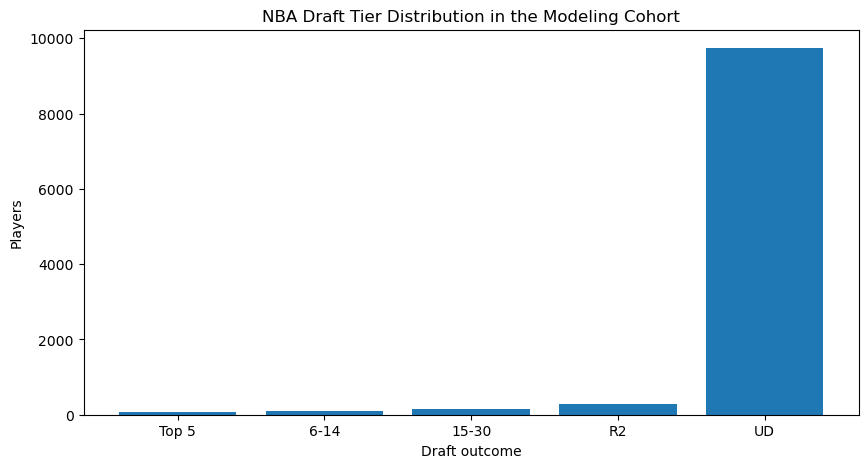

In [18]:
plt.figure(figsize=(10, 5))
counts = model_df["draft_outcome"].value_counts().reindex(CLASS_NAMES, fill_value=0)
plt.bar(CLASS_SHORT, counts.values)
plt.title("NBA Draft Tier Distribution in the Modeling Cohort")
plt.xlabel("Draft outcome")
plt.ylabel("Players")
plt.show()

# Part V — Exploratory analysis

## 14. Draft-tier mix by year

Because the NCAA match rate and the source-data coverage change over time, inspect the class composition before fitting a model.

draft_outcome,Top 5,Lottery (6-14),Rest of 1st (15-30),2nd Round,Undrafted
anchor_year,,,,,
2014,2,6,5,12,480
2015,2,6,8,14,495
2016,4,5,6,16,497
2017,5,6,5,17,495
2018,3,5,5,17,480
2019,3,6,6,18,521
2020,2,4,10,21,503
2021,3,2,9,16,410
2022,5,4,9,10,530


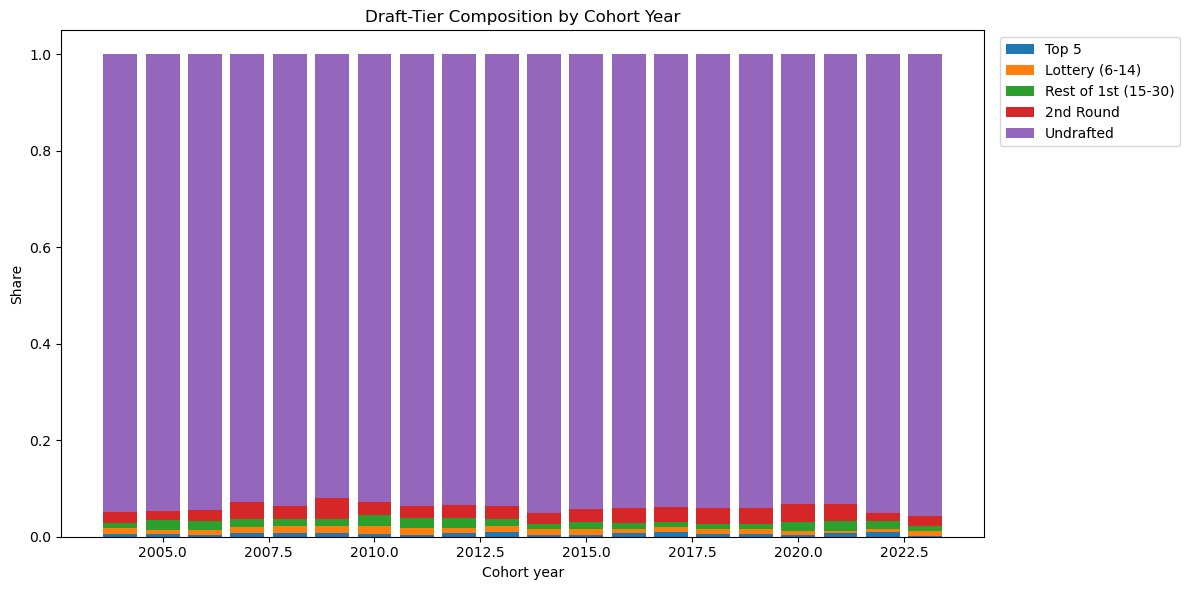

In [19]:
yearly_tiers = (
    model_df.groupby(["anchor_year", "draft_outcome"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_NAMES, fill_value=0)
)

display(yearly_tiers.tail(10))

share_by_year = yearly_tiers.div(yearly_tiers.sum(axis=1), axis=0)
plt.figure(figsize=(12, 6))
bottom = np.zeros(len(share_by_year))
for col in CLASS_NAMES:
    vals = share_by_year[col].to_numpy()
    plt.bar(share_by_year.index, vals, bottom=bottom, label=col)
    bottom += vals
plt.title("Draft-Tier Composition by Cohort Year")
plt.xlabel("Cohort year")
plt.ylabel("Share")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# Part VI — Leakage audit and feature sets

## 15. Leakage audit

### Never used as predictors

The following columns reveal or directly encode the historical draft result and are excluded:

- `draft_year`
- `draft_pos`
- `drafted`
- `is_drafted`
- `target`
- `draft_outcome`
- `match_method`
- `career_id` / name keys

`anchor_year` is used only for temporal splitting. It is also excluded from predictors so the model cannot exploit shifts in class composition by calendar year.

The underlying statistical features are all constructed from NCAA seasons at or before the cohort anchor.

In [20]:
LEAKAGE_COLS = {
    "career_id", "player", "player_key", "player_key_loose",
    "first_year", "last_year", "observed_seasons",
    "draft_year", "draft_pos", "drafted", "match_method", "is_drafted",
    "anchor_year", "target", "draft_outcome",
}

feature_cols = [
    c for c in model_df.columns
    if c not in LEAKAGE_COLS and pd.api.types.is_numeric_dtype(model_df[c])
]

print("Total model features:", len(feature_cols))
assert not any(c in feature_cols for c in LEAKAGE_COLS)

Total model features: 78


## 16. Define three compact information sets for ablation

The ablation tests whether the model benefits from combining a player's latest NCAA season with the broader career average.

- **Final season:** original NCAA statistics from the final observed season
- **Career average:** career-average versions of the same NCAA statistics
- **Combined:** both views plus minimal career context

In [21]:
context_features = [c for c in ["seasons_observed", "career_games"] if c in feature_cols]
final_features = sorted([c for c in feature_cols if c.startswith("final_")])
career_mean_features = sorted([c for c in feature_cols if c.startswith("career_mean_")])
combined_features = sorted(set(context_features + final_features + career_mean_features))

FEATURE_SETS = {
    "final_season": final_features,
    "career_average": career_mean_features,
    "combined": combined_features,
}

pd.DataFrame(
    {name: [len(cols)] for name, cols in FEATURE_SETS.items()},
    index=["feature_count"],
).T

,feature_count
final_season,38
career_average,38
combined,78


# Part VII — Time-aware split and preprocessing

## 17. Create train, validation, and untouched test cohorts

In [22]:
train_df = model_df[model_df["anchor_year"] <= TRAIN_END].copy()
valid_df = model_df[model_df["anchor_year"].isin(VALID_YEARS)].copy()
test_df = model_df[model_df["anchor_year"].isin(TEST_YEARS)].copy()

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(valid_df), len(test_df)],
    "min_year": [train_df.anchor_year.min(), valid_df.anchor_year.min(), test_df.anchor_year.min()],
    "max_year": [train_df.anchor_year.max(), valid_df.anchor_year.max(), test_df.anchor_year.max()],
})
split_summary

,split,rows,min_year,max_year
0,train,7639,2004,2018
1,validation,1534,2019,2021
2,test,1199,2022,2023


In [23]:
for name, frame in [("train", train_df), ("validation", valid_df), ("test", test_df)]:
    print(f"\n{name.upper()}")
    display(
        frame["draft_outcome"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
        .to_frame("players")
        .T
    )


TRAIN


draft_outcome,Top 5,Lottery (6-14),Rest of 1st (15-30),2nd Round,Undrafted
players,50,90,118,216,7165



VALIDATION


draft_outcome,Top 5,Lottery (6-14),Rest of 1st (15-30),2nd Round,Undrafted
players,8,12,25,55,1434



TEST


draft_outcome,Top 5,Lottery (6-14),Rest of 1st (15-30),2nd Round,Undrafted
players,6,10,16,23,1144


## 18. Robust numeric preprocessing

All model features are numeric. Missing values are median-imputed **inside each training pipeline**, preventing validation/test information from entering the imputation statistics.

Linear models additionally receive robust scaling. Tree models use median imputation without scaling.

In [24]:
def build_numeric_preprocessor(cols, scale=False):
    steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale:
        steps.append(("scaler", RobustScaler()))
    return ColumnTransformer([
        ("num", Pipeline(steps), cols),
    ], remainder="drop", verbose_feature_names_out=False)


def make_logistic(cols):
    return Pipeline([
        ("preprocess", build_numeric_preprocessor(cols, scale=True)),
        ("model", LogisticRegression(
            max_iter=600,
            tol=1e-3,
            solver="saga",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ])


def make_random_forest(cols):
    return Pipeline([
        ("preprocess", build_numeric_preprocessor(cols, scale=False)),
        ("model", RandomForestClassifier(
            n_estimators=600,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        )),
    ])


def make_xgb(cols, **params):
    defaults = dict(
        objective="multi:softprob",
        num_class=N_CLASSES,
        eval_metric="mlogloss",
        n_estimators=500,
        learning_rate=0.04,
        max_depth=4,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.80,
        reg_alpha=0.05,
        reg_lambda=2.0,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
    defaults.update(params)
    return Pipeline([
        ("preprocess", build_numeric_preprocessor(cols, scale=False)),
        ("model", XGBClassifier(**defaults)),
    ])

# Part VIII — Ordinal-aware evaluation

## 19. Metrics that respect ordered draft tiers

In addition to exact class accuracy and macro-F1, the notebook reports:

- **within-one-tier accuracy**,
- **expected-tier MAE** using the full probability distribution,
- **quadratic weighted kappa**, which penalizes distant errors more heavily,
- **log loss**, which evaluates probability quality.

In [25]:
def align_proba(proba, model_classes=None):
    proba = np.asarray(proba)
    if proba.shape[1] == N_CLASSES and model_classes is None:
        return proba
    out = np.zeros((len(proba), N_CLASSES), dtype=float)
    if model_classes is None:
        model_classes = np.arange(proba.shape[1])
    for j, cls in enumerate(model_classes):
        out[:, int(cls)] = proba[:, j]
    row_sum = out.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    return out / row_sum


def expected_tier_from_proba(proba):
    return np.asarray(proba) @ CLASS_INDEX


def classification_metrics(y_true, pred, proba, model_name):
    y_true = np.asarray(y_true, dtype=int)
    pred = np.asarray(pred, dtype=int)
    proba = np.asarray(proba, dtype=float)
    expected = expected_tier_from_proba(proba)
    return pd.Series({
        "model": model_name,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "macro_f1": f1_score(y_true, pred, average="macro", zero_division=0),
        "within_1_tier": np.mean(np.abs(pred - y_true) <= 1),
        "class_mae": np.mean(np.abs(pred - y_true)),
        "expected_tier_mae": np.mean(np.abs(expected - y_true)),
        "qwk": cohen_kappa_score(y_true, pred, weights="quadratic"),
        "log_loss": log_loss(y_true, proba, labels=CLASS_INDEX),
    })


def fit_with_balanced_weights(model, X, y):
    weights = compute_sample_weight(class_weight="balanced", y=y)
    try:
        model.fit(X, y, model__sample_weight=weights)
    except TypeError:
        model.fit(X, y)
    return model

# Part IX — Baseline model comparison

## 20. Evaluate simple baselines on the validation period

In [26]:
full_cols = FEATURE_SETS["combined"]
X_train = train_df[full_cols]
y_train = train_df["target"].astype(int)
X_valid = valid_df[full_cols]
y_valid = valid_df["target"].astype(int)

baseline_results = []
validation_predictions = {}

# Most-frequent baseline
most_frequent = DummyClassifier(strategy="most_frequent")
most_frequent.fit(X_train, y_train)
proba = align_proba(most_frequent.predict_proba(X_valid), most_frequent.classes_)
pred = proba.argmax(axis=1)
baseline_results.append(classification_metrics(y_valid, pred, proba, "Most Frequent"))
validation_predictions["Most Frequent"] = (pred, proba)

# Logistic regression
logit = make_logistic(full_cols)
logit.fit(X_train, y_train)
proba = align_proba(logit.predict_proba(X_valid), logit.named_steps["model"].classes_)
pred = proba.argmax(axis=1)
baseline_results.append(classification_metrics(y_valid, pred, proba, "Multinomial Logistic"))
validation_predictions["Multinomial Logistic"] = (pred, proba)

# Random forest
rf = make_random_forest(full_cols)
rf.fit(X_train, y_train)
proba = align_proba(rf.predict_proba(X_valid), rf.named_steps["model"].classes_)
pred = proba.argmax(axis=1)
baseline_results.append(classification_metrics(y_valid, pred, proba, "Random Forest"))
validation_predictions["Random Forest"] = (pred, proba)

# Untuned multiclass XGBoost
xgb_base = make_xgb(full_cols)
fit_with_balanced_weights(xgb_base, X_train, y_train)
proba = align_proba(xgb_base.predict_proba(X_valid))
pred = proba.argmax(axis=1)
baseline_results.append(classification_metrics(y_valid, pred, proba, "XGBoost"))
validation_predictions["XGBoost"] = (pred, proba)

baseline_table = pd.DataFrame(baseline_results).set_index("model").sort_values("expected_tier_mae")
baseline_table

,accuracy,balanced_accuracy,macro_f1,within_1_tier,class_mae,expected_tier_mae,qwk,log_loss
model,,,,,,,,
Most Frequent,0.935,0.200,0.193,0.971,0.113,0.113,0.000,2.350
XGBoost,0.889,0.337,0.321,0.956,0.171,0.235,0.417,0.345
Random Forest,0.933,0.318,0.350,0.974,0.106,0.243,0.363,0.339
Multinomial Logistic,0.751,0.427,0.299,0.911,0.365,0.555,0.328,0.748


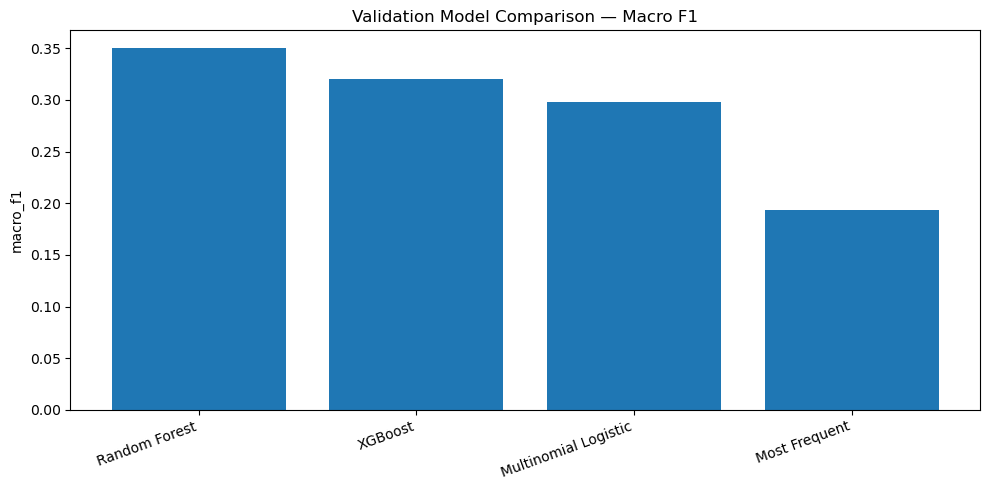

In [27]:
metric = "macro_f1"
plt.figure(figsize=(10, 5))
ordered = baseline_table.sort_values(metric, ascending=False)
plt.bar(ordered.index, ordered[metric])
plt.title("Validation Model Comparison — Macro F1")
plt.ylabel(metric)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Part X — Custom cumulative ordinal model

## 21. Reframe five classes as four ordered binary questions

A cumulative ordinal model learns:

- Is the player worse than Top 5?
- Is the player worse than Lottery?
- Is the player worse than the rest of Round 1?
- Is the player Undrafted rather than selected in Round 2?

Each threshold is fit with a binary XGBoost model. The cumulative probabilities are then converted back into a five-class distribution.

In [28]:
class CumulativeOrdinalXGB(BaseEstimator, ClassifierMixin):
    def __init__(self, n_classes=N_CLASSES, **xgb_params):
        self.n_classes = n_classes
        self.xgb_params = xgb_params

    def fit(self, X, y):
        y = np.asarray(y, dtype=int)
        self.classes_ = np.arange(self.n_classes)
        self.models_ = []
        for threshold in range(self.n_classes - 1):
            y_binary = (y > threshold).astype(int)
            model = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                n_jobs=N_JOBS,
                random_state=RANDOM_STATE,
                **self.xgb_params,
            )
            weights = compute_sample_weight(class_weight="balanced", y=y_binary)
            model.fit(X, y_binary, sample_weight=weights)
            self.models_.append(model)
        return self

    def predict_proba(self, X):
        # P(y > threshold) for each ordered cut point.
        gt = np.column_stack([m.predict_proba(X)[:, 1] for m in self.models_])

        # Enforce monotonic cumulative probabilities: P(y>0) >= P(y>1) >= ...
        gt = np.minimum.accumulate(gt, axis=1)

        proba = np.zeros((len(gt), self.n_classes), dtype=float)
        proba[:, 0] = 1.0 - gt[:, 0]
        for cls in range(1, self.n_classes - 1):
            proba[:, cls] = gt[:, cls - 1] - gt[:, cls]
        proba[:, -1] = gt[:, -1]

        proba = np.clip(proba, 0, None)
        row_sum = proba.sum(axis=1, keepdims=True)
        row_sum[row_sum == 0] = 1
        return proba / row_sum

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

In [29]:
ordinal_preprocess = build_numeric_preprocessor(full_cols, scale=False)
X_train_ord = ordinal_preprocess.fit_transform(X_train)
X_valid_ord = ordinal_preprocess.transform(X_valid)

ordinal_base = CumulativeOrdinalXGB(
    n_classes=N_CLASSES,
    n_estimators=450,
    learning_rate=0.04,
    max_depth=4,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.80,
    reg_alpha=0.05,
    reg_lambda=2.0,
)
ordinal_base.fit(X_train_ord, y_train)
ordinal_valid_proba = ordinal_base.predict_proba(X_valid_ord)
ordinal_valid_pred = ordinal_valid_proba.argmax(axis=1)

ordinal_base_metrics = classification_metrics(
    y_valid,
    ordinal_valid_pred,
    ordinal_valid_proba,
    "Cumulative Ordinal XGBoost",
)
ordinal_base_metrics.to_frame("value")

,value
model,Cumulative Ordinal XGBoost
accuracy,0.899
balanced_accuracy,0.366
macro_f1,0.329
within_1_tier,0.958
class_mae,0.160
expected_tier_mae,0.220
qwk,0.472
log_loss,0.531


# Part XI — Bayesian optimization

## 22. Optuna TPE with expanding-window validation

Each Optuna trial trains XGBoost on earlier draft cohorts and evaluates it on a later cohort. The objective combines:

- **expected-tier MAE** — ordinal distance from the true outcome,
- **macro-F1 penalty** — prevents the search from achieving a low average distance by ignoring minority draft tiers.

The objective is minimized:

\[
\text{score}=\text{ExpectedTierMAE}+0.25(1-\text{MacroF1})
\]

This gives the search an ordinal primary objective while still rewarding separation of all five classes.

In [30]:
OPTUNA_VALIDATION_YEARS = [2015, 2016, 2017, 2018]
optuna_frame = train_df.copy()


def temporal_fold_score(params, valid_year):
    fold_train = optuna_frame[optuna_frame["anchor_year"] < valid_year]
    fold_valid = optuna_frame[optuna_frame["anchor_year"] == valid_year]

    if fold_train.empty or fold_valid.empty:
        return None

    X_tr = fold_train[full_cols]
    y_tr = fold_train["target"].astype(int)
    X_va = fold_valid[full_cols]
    y_va = fold_valid["target"].astype(int)

    model = make_xgb(full_cols, **params)
    fit_with_balanced_weights(model, X_tr, y_tr)
    proba = align_proba(model.predict_proba(X_va))
    pred = proba.argmax(axis=1)

    expected_mae = np.mean(np.abs(expected_tier_from_proba(proba) - y_va.to_numpy()))
    macro_f1 = f1_score(y_va, pred, average="macro", zero_division=0)
    return expected_mae + 0.25 * (1.0 - macro_f1)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 30.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 1.00),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),
    }

    fold_scores = []
    for valid_year in OPTUNA_VALIDATION_YEARS:
        score = temporal_fold_score(params, valid_year)
        if score is not None and np.isfinite(score):
            fold_scores.append(score)

    if not fold_scores:
        return float("inf")
    return float(np.mean(fold_scores))

sampler = TPESampler(seed=RANDOM_STATE, n_startup_trials=min(12, N_TRIALS))
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best objective:", study.best_value)
print("Best parameters:")
study.best_params

[I 2026-08-20 23:01:33,960] A new study created in memory with name: no-name-fdb6af09-d633-4b40-b9de-30b6d34d1b0c


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-08-20 23:01:38,714] Trial 0 finished with value: 0.37052360623671876 and parameters: {'n_estimators': 500, 'learning_rate': 0.13125830316209655, 'max_depth': 6, 'min_child_weight': 7.6611007077713635, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.6201975341512912, 'gamma': 0.2904180608409973, 'reg_alpha': 1.5741890047456624, 'reg_lambda': 0.667761551174708}. Best is trial 0 with value: 0.37052360623671876.
[I 2026-08-20 23:01:53,819] Trial 1 finished with value: 0.49534420449899863 and parameters: {'n_estimators': 800, 'learning_rate': 0.010573268083515799, 'max_depth': 7, 'min_child_weight': 16.967533607196547, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6318212352431953, 'gamma': 0.9170225492671691, 'reg_alpha': 0.0006690421166498799, 'reg_lambda': 0.29229052129200933}. Best is trial 0 with value: 0.37052360623671876.
[I 2026-08-20 23:02:02,127] Trial 2 finished with value: 0.4888224334397098 and parameters: {'n_estimators': 600, 'learning_rate': 0.0220045

{'n_estimators': 900,
 'learning_rate': 0.07014390053746902,
 'max_depth': 4,
 'min_child_weight': 2.0910618873127063,
 'subsample': 0.6994635459834267,
 'colsample_bytree': 0.7315926747505537,
 'gamma': 0.008905271500622071,
 'reg_alpha': 1.2200103688693218e-05,
 'reg_lambda': 0.036447969299155496}

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
25,25,0.295,2026-08-20 23:04:37.193546,2026-08-20 23:04:47.613837,0 days 00:00:10.420291,0.732,0.009,0.070,4,2.091,900,0.000,0.036,0.699,COMPLETE
32,32,0.297,2026-08-20 23:05:35.686074,2026-08-20 23:05:44.382673,0 days 00:00:08.696599,0.621,0.012,0.115,4,2.134,900,0.152,0.343,0.829,COMPLETE
31,31,0.304,2026-08-20 23:05:26.765897,2026-08-20 23:05:35.685371,0 days 00:00:08.919474,0.640,0.019,0.125,3,2.221,1000,0.040,0.661,0.834,COMPLETE
12,12,0.305,2026-08-20 23:02:54.199735,2026-08-20 23:03:03.122115,0 days 00:00:08.922380,0.678,0.060,0.134,3,1.039,1000,0.051,0.882,0.606,COMPLETE
18,18,0.316,2026-08-20 23:03:40.805687,2026-08-20 23:03:51.375749,0 days 00:00:10.570062,0.719,0.002,0.062,4,3.926,900,0.230,0.048,0.603,COMPLETE
13,13,0.329,2026-08-20 23:03:03.122870,2026-08-20 23:03:11.115287,0 days 00:00:07.992417,0.668,0.055,0.148,3,17.088,1000,0.067,0.726,0.790,COMPLETE
21,21,0.335,2026-08-20 23:04:06.244818,2026-08-20 23:04:14.875519,0 days 00:00:08.630701,0.657,0.054,0.110,3,9.970,1000,0.098,0.278,0.630,COMPLETE
23,23,0.347,2026-08-20 23:04:21.434947,2026-08-20 23:04:28.561851,0 days 00:00:07.126904,0.666,0.568,0.091,4,2.852,900,0.020,0.510,0.601,COMPLETE
26,26,0.350,2026-08-20 23:04:47.614608,2026-08-20 23:04:54.906507,0 days 00:00:07.291899,0.749,0.466,0.071,4,1.965,800,0.000,0.025,0.703,COMPLETE
34,34,0.353,2026-08-20 23:05:50.876894,2026-08-20 23:05:56.447147,0 days 00:00:05.570253,0.618,0.387,0.123,4,1.398,800,0.032,2.557,0.840,COMPLETE


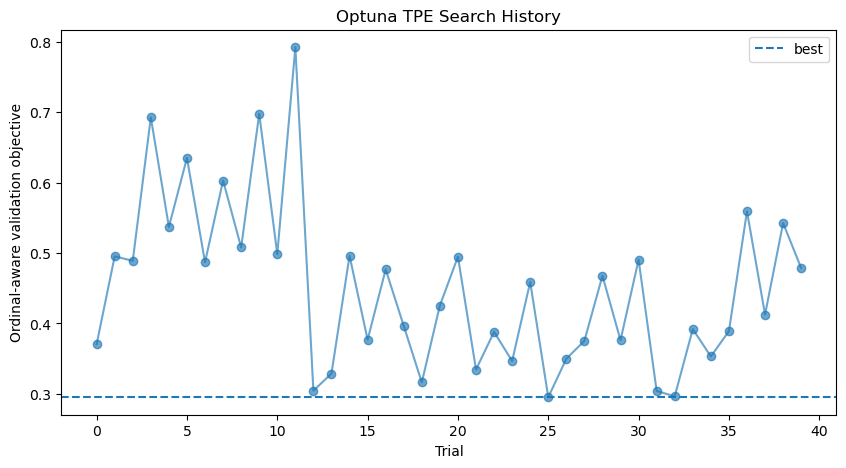

In [31]:
trials_df = study.trials_dataframe()
display(trials_df.sort_values("value").head(10))

plt.figure(figsize=(10, 5))
plt.plot(trials_df["number"], trials_df["value"], marker="o", alpha=0.65)
plt.axhline(study.best_value, linestyle="--", label="best")
plt.title("Optuna TPE Search History")
plt.xlabel("Trial")
plt.ylabel("Ordinal-aware validation objective")
plt.legend()
plt.show()

## 23. Fit the tuned multiclass model and tuned ordinal model on the training period

In [32]:
best_params = study.best_params.copy()

tuned_xgb = make_xgb(full_cols, **best_params)
fit_with_balanced_weights(tuned_xgb, X_train, y_train)

tuned_valid_proba = align_proba(tuned_xgb.predict_proba(X_valid))
tuned_valid_pred = tuned_valid_proba.argmax(axis=1)
tuned_metrics = classification_metrics(
    y_valid, tuned_valid_pred, tuned_valid_proba, "Bayesian-Tuned XGBoost"
)

# Reuse the same tuned tree hyperparameters in the cumulative ordinal construction.
ordinal_tuned_preprocess = build_numeric_preprocessor(full_cols, scale=False)
X_train_ord_tuned = ordinal_tuned_preprocess.fit_transform(X_train)
X_valid_ord_tuned = ordinal_tuned_preprocess.transform(X_valid)

ordinal_tuned = CumulativeOrdinalXGB(n_classes=N_CLASSES, **best_params)
ordinal_tuned.fit(X_train_ord_tuned, y_train)
ordinal_tuned_valid_proba = ordinal_tuned.predict_proba(X_valid_ord_tuned)
ordinal_tuned_valid_pred = ordinal_tuned_valid_proba.argmax(axis=1)
ordinal_tuned_metrics = classification_metrics(
    y_valid,
    ordinal_tuned_valid_pred,
    ordinal_tuned_valid_proba,
    "Bayesian-Tuned Ordinal XGBoost",
)

pd.DataFrame([tuned_metrics, ordinal_tuned_metrics]).set_index("model")

,accuracy,balanced_accuracy,macro_f1,within_1_tier,class_mae,expected_tier_mae,qwk,log_loss
model,,,,,,,,
Bayesian-Tuned XGBoost,0.924,0.348,0.359,0.972,0.116,0.130,0.473,0.345
Bayesian-Tuned Ordinal XGBoost,0.915,0.402,0.419,0.971,0.126,0.143,0.483,0.804


# Part XII — Probability ensemble

## 24. Blend multiclass and ordinal XGBoost probabilities

The two models solve the same task differently. A small validation-only grid search chooses the blend weight that minimizes expected-tier MAE.

In [33]:
blend_rows = []
for w in np.linspace(0, 1, 21):
    blend = w * tuned_valid_proba + (1 - w) * ordinal_tuned_valid_proba
    pred = blend.argmax(axis=1)
    metrics = classification_metrics(y_valid, pred, blend, f"blend_{w:.2f}")
    blend_rows.append({"weight_multiclass": w, **metrics.to_dict()})

blend_table = pd.DataFrame(blend_rows).sort_values([
    "expected_tier_mae", "macro_f1"
], ascending=[True, False])

display(blend_table.head(10))
BEST_BLEND_WEIGHT = float(blend_table.iloc[0]["weight_multiclass"])
print("Selected multiclass probability weight:", BEST_BLEND_WEIGHT)

,weight_multiclass,model,accuracy,balanced_accuracy,macro_f1,within_1_tier,class_mae,expected_tier_mae,qwk,log_loss
20,1.000,blend_1.00,0.924,0.348,0.359,0.972,0.116,0.130,0.473,0.345
19,0.950,blend_0.95,0.925,0.352,0.362,0.971,0.117,0.131,0.469,0.342
18,0.900,blend_0.90,0.924,0.352,0.362,0.971,0.117,0.131,0.468,0.341
17,0.850,blend_0.85,0.924,0.352,0.361,0.971,0.119,0.132,0.465,0.340
16,0.800,blend_0.80,0.924,0.352,0.361,0.971,0.119,0.132,0.465,0.340
15,0.750,blend_0.75,0.924,0.352,0.366,0.972,0.117,0.133,0.467,0.340
14,0.700,blend_0.70,0.923,0.351,0.365,0.971,0.119,0.133,0.463,0.341
13,0.650,blend_0.65,0.923,0.351,0.364,0.971,0.119,0.134,0.466,0.342
12,0.600,blend_0.60,0.923,0.368,0.383,0.971,0.119,0.135,0.463,0.344
11,0.550,blend_0.55,0.925,0.397,0.415,0.972,0.115,0.135,0.473,0.346


Selected multiclass probability weight: 1.0


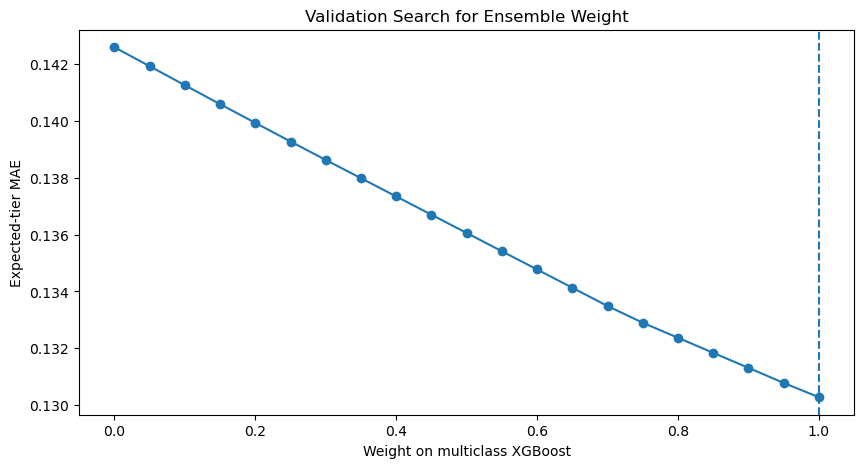

In [34]:
plt.figure(figsize=(10, 5))
plot_blend = pd.DataFrame(blend_rows).sort_values("weight_multiclass")
plt.plot(plot_blend["weight_multiclass"], plot_blend["expected_tier_mae"], marker="o")
plt.axvline(BEST_BLEND_WEIGHT, linestyle="--")
plt.title("Validation Search for Ensemble Weight")
plt.xlabel("Weight on multiclass XGBoost")
plt.ylabel("Expected-tier MAE")
plt.show()

# Part XIII — Final untouched test

## 25. Retrain on all pre-test data, then evaluate 2022–2023 once

After model and ensemble choices are fixed using the validation period, training and validation data are combined. The 2022–2023 cohorts remain untouched until this point.

In [35]:
dev_df = pd.concat([train_df, valid_df], ignore_index=True).sort_values("anchor_year")
X_dev = dev_df[full_cols]
y_dev = dev_df["target"].astype(int)
X_test = test_df[full_cols]
y_test = test_df["target"].astype(int)

final_multiclass = make_xgb(full_cols, **best_params)
fit_with_balanced_weights(final_multiclass, X_dev, y_dev)

final_ordinal_preprocess = build_numeric_preprocessor(full_cols, scale=False)
X_dev_ord = final_ordinal_preprocess.fit_transform(X_dev)
X_test_ord = final_ordinal_preprocess.transform(X_test)
final_ordinal = CumulativeOrdinalXGB(n_classes=N_CLASSES, **best_params)
final_ordinal.fit(X_dev_ord, y_dev)

multi_test_proba = align_proba(final_multiclass.predict_proba(X_test))
ordinal_test_proba = final_ordinal.predict_proba(X_test_ord)
final_test_proba = (
    BEST_BLEND_WEIGHT * multi_test_proba
    + (1 - BEST_BLEND_WEIGHT) * ordinal_test_proba
)
final_test_pred = final_test_proba.argmax(axis=1)

final_metrics = classification_metrics(
    y_test, final_test_pred, final_test_proba, "Final Probability Ensemble"
)
final_metrics.to_frame("value")

,value
model,Final Probability Ensemble
accuracy,0.936
balanced_accuracy,0.296
macro_f1,0.301
within_1_tier,0.971
class_mae,0.105
expected_tier_mae,0.120
qwk,0.451
log_loss,0.226


## 26. Compare every major model on the untouched test period

In [36]:
test_model_rows = []

# Logistic
logit_final = make_logistic(full_cols)
logit_final.fit(X_dev, y_dev)
p = align_proba(logit_final.predict_proba(X_test), logit_final.named_steps["model"].classes_)
test_model_rows.append(classification_metrics(y_test, p.argmax(axis=1), p, "Multinomial Logistic"))

# Random forest
rf_final = make_random_forest(full_cols)
rf_final.fit(X_dev, y_dev)
p = align_proba(rf_final.predict_proba(X_test), rf_final.named_steps["model"].classes_)
test_model_rows.append(classification_metrics(y_test, p.argmax(axis=1), p, "Random Forest"))

# Tuned multiclass
p = multi_test_proba
test_model_rows.append(classification_metrics(y_test, p.argmax(axis=1), p, "Bayesian-Tuned XGBoost"))

# Tuned ordinal
p = ordinal_test_proba
test_model_rows.append(classification_metrics(y_test, p.argmax(axis=1), p, "Bayesian-Tuned Ordinal XGBoost"))

# Ensemble
p = final_test_proba
test_model_rows.append(classification_metrics(y_test, p.argmax(axis=1), p, "Probability Ensemble"))

test_model_table = pd.DataFrame(test_model_rows).set_index("model").sort_values("expected_tier_mae")
test_model_table

,accuracy,balanced_accuracy,macro_f1,within_1_tier,class_mae,expected_tier_mae,qwk,log_loss
model,,,,,,,,
Bayesian-Tuned XGBoost,0.936,0.296,0.301,0.971,0.105,0.120,0.451,0.226
Probability Ensemble,0.936,0.296,0.301,0.971,0.105,0.120,0.451,0.226
Bayesian-Tuned Ordinal XGBoost,0.929,0.366,0.338,0.968,0.118,0.134,0.472,0.440
Random Forest,0.954,0.308,0.330,0.974,0.086,0.236,0.318,0.227
Multinomial Logistic,0.761,0.396,0.277,0.907,0.374,0.620,0.289,0.737


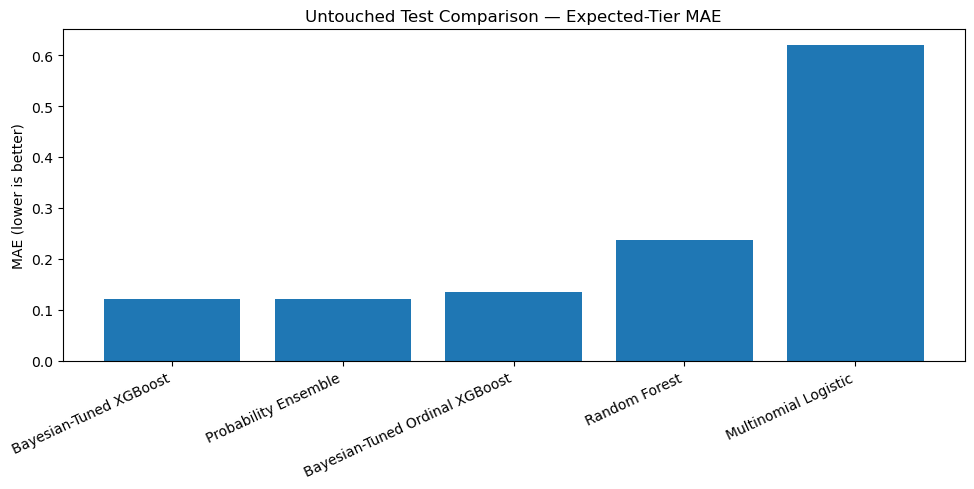

In [37]:
plt.figure(figsize=(10, 5))
ordered = test_model_table.sort_values("expected_tier_mae")
plt.bar(ordered.index, ordered["expected_tier_mae"])
plt.title("Untouched Test Comparison — Expected-Tier MAE")
plt.ylabel("MAE (lower is better)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 27. Five-by-five confusion matrix

For an ordered target, a healthy confusion matrix should concentrate errors close to the diagonal.

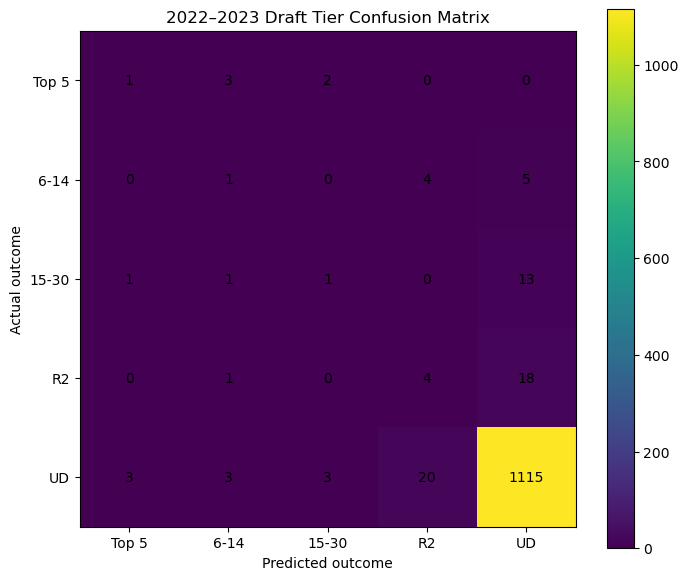

In [38]:
cm = confusion_matrix(y_test, final_test_pred, labels=CLASS_INDEX)
fig, ax = plt.subplots(figsize=(8, 7))
img = ax.imshow(cm)
ax.set_xticks(CLASS_INDEX)
ax.set_xticklabels(CLASS_SHORT)
ax.set_yticks(CLASS_INDEX)
ax.set_yticklabels(CLASS_SHORT)
ax.set_xlabel("Predicted outcome")
ax.set_ylabel("Actual outcome")
ax.set_title("2022–2023 Draft Tier Confusion Matrix")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center")
fig.colorbar(img, ax=ax)
plt.show()

In [39]:
report = classification_report(
    y_test,
    final_test_pred,
    labels=CLASS_INDEX,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T.loc[
    CLASS_NAMES,
    ["precision", "recall", "f1-score", "support"],
]
report_df

,precision,recall,f1-score,support
Top 5,0.200,0.167,0.182,6.000
Lottery (6-14),0.111,0.100,0.105,10.000
Rest of 1st (15-30),0.167,0.062,0.091,16.000
2nd Round,0.143,0.174,0.157,23.000
Undrafted,0.969,0.975,0.972,"1,144.000"


## 28. How far away are the mistakes?

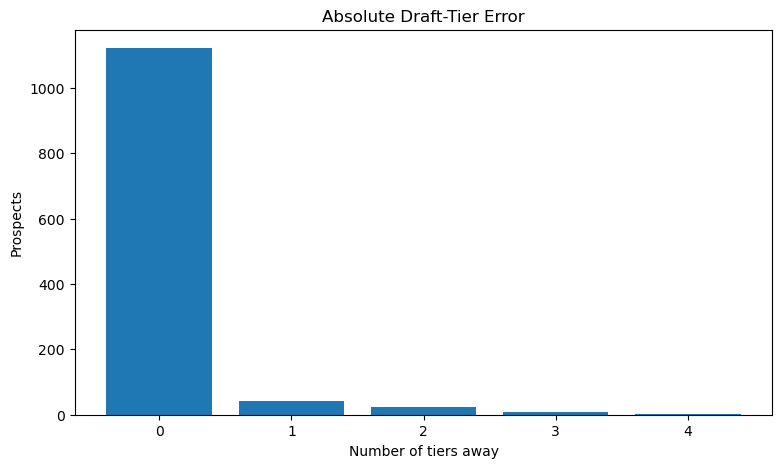

,metric,share
0,exact,0.936
1,within_1,0.971
2,within_2,0.991


In [40]:
tier_distance = np.abs(final_test_pred - y_test.to_numpy())
distance_counts = pd.Series(tier_distance).value_counts().sort_index()

plt.figure(figsize=(9, 5))
plt.bar(distance_counts.index.astype(str), distance_counts.values)
plt.title("Absolute Draft-Tier Error")
plt.xlabel("Number of tiers away")
plt.ylabel("Prospects")
plt.show()

pd.DataFrame({
    "metric": ["exact", "within_1", "within_2"],
    "share": [
        np.mean(tier_distance == 0),
        np.mean(tier_distance <= 1),
        np.mean(tier_distance <= 2),
    ],
})

# Part XIV — Prospect-level probability analysis

## 29. Build an interpretable test prediction table

Expected tier is a continuous summary of the five-class probability distribution:

- 0 ≈ Top 5
- 1 ≈ Lottery
- 2 ≈ Rest of 1st
- 3 ≈ 2nd Round
- 4 ≈ Undrafted

In [41]:
def normalized_entropy(proba):
    p = np.clip(np.asarray(proba), 1e-12, 1)
    return -(p * np.log(p)).sum(axis=1) / np.log(p.shape[1])

results_test = test_df[[
    "career_id", "player", "anchor_year", "draft_outcome", "drafted", "draft_pos"
]].copy().reset_index(drop=True)
results_test["actual_target"] = y_test.to_numpy()
results_test["predicted_target"] = final_test_pred
results_test["predicted_outcome"] = [CLASS_NAMES[i] for i in final_test_pred]
results_test["expected_tier"] = expected_tier_from_proba(final_test_proba)
results_test["confidence"] = final_test_proba.max(axis=1)
results_test["normalized_entropy"] = normalized_entropy(final_test_proba)
results_test["tier_distance"] = np.abs(results_test["predicted_target"] - results_test["actual_target"])
results_test["draft_probability"] = 1 - final_test_proba[:, 4]
results_test["first_round_probability"] = final_test_proba[:, :3].sum(axis=1)
results_test["lottery_probability"] = final_test_proba[:, :2].sum(axis=1)

for i, cls in enumerate(CLASS_NAMES):
    safe = re.sub(r"[^a-z0-9]+", "_", cls.lower()).strip("_")
    results_test[f"p_{safe}"] = final_test_proba[:, i]

results_test.sort_values(["anchor_year", "expected_tier"]).head(25)

,career_id,player,anchor_year,draft_outcome,drafted,draft_pos,actual_target,predicted_target,predicted_outcome,expected_tier,confidence,normalized_entropy,tier_distance,draft_probability,first_round_probability,lottery_probability,p_top_5,p_lottery_6_14,p_rest_of_1st_15_30,p_2nd_round,p_undrafted
1058,tari eason__0,Tari Eason,2022,Rest of 1st (15-30),first round,17.000,2,0,Top 5,0.663,0.630,0.624,2,0.936,0.892,0.880,0.630,0.250,0.012,0.044,0.064
465,jabari smith jr__0,"Jabari Smith, Jr.",2022,Top 5,first round,3.000,0,0,Top 5,0.984,0.615,0.693,0,0.967,0.760,0.675,0.615,0.060,0.085,0.207,0.033
933,paolo banchero__0,Paolo Banchero,2022,Top 5,first round,1.000,0,1,Lottery (6-14),1.122,0.498,0.700,1,0.995,0.808,0.787,0.288,0.498,0.021,0.187,0.005
925,orlando robinson__0,Orlando Robinson,2022,Undrafted,NaN,NaN,4,0,Top 5,1.253,0.558,0.701,4,0.943,0.648,0.598,0.558,0.040,0.051,0.295,0.057
193,chet holmgren__0,Chet Holmgren,2022,Top 5,first round,2.000,0,1,Lottery (6-14),1.480,0.598,0.681,1,0.813,0.777,0.764,0.166,0.598,0.013,0.036,0.187
488,jaden ivey__0,Jaden Ivey,2022,Top 5,first round,5.000,0,1,Lottery (6-14),1.514,0.751,0.469,1,0.958,0.774,0.752,0.002,0.751,0.022,0.183,0.042
704,keegan murray__0,Keegan Murray,2022,Top 5,first round,4.000,0,2,Rest of 1st (15-30),1.628,0.442,0.838,2,0.917,0.800,0.358,0.297,0.061,0.442,0.117,0.083
204,christian koloko__0,Christian Koloko,2022,2nd Round,second round,3.000,3,1,Lottery (6-14),1.764,0.467,0.824,2,0.914,0.772,0.508,0.041,0.467,0.264,0.142,0.086
379,fardaws aimaq__0,Fardaws Aimaq,2022,Undrafted,NaN,NaN,4,0,Top 5,1.957,0.367,0.881,4,0.757,0.520,0.399,0.367,0.032,0.121,0.237,0.243
807,mark williams__1,Mark Williams,2022,Rest of 1st (15-30),first round,15.000,2,1,Lottery (6-14),1.968,0.365,0.933,1,0.767,0.600,0.515,0.150,0.365,0.086,0.167,0.233


## 30. Highest model-rated prospects in the test period

In [42]:
results_test.sort_values(["expected_tier", "confidence"]).head(30)[[
    "player", "anchor_year", "draft_outcome", "predicted_outcome",
    "expected_tier", "lottery_probability", "first_round_probability",
    "draft_probability", "confidence",
]]

,player,anchor_year,draft_outcome,predicted_outcome,expected_tier,lottery_probability,first_round_probability,draft_probability,confidence
1058,Tari Eason,2022,Rest of 1st (15-30),Top 5,0.663,0.880,0.892,0.936,0.630
465,"Jabari Smith, Jr.",2022,Top 5,Top 5,0.984,0.675,0.760,0.967,0.615
87,Aziz Bandaogo,2023,Undrafted,Top 5,1.005,0.659,0.828,0.863,0.645
933,Paolo Banchero,2022,Top 5,Lottery (6-14),1.122,0.787,0.808,0.995,0.498
925,Orlando Robinson,2022,Undrafted,Top 5,1.253,0.598,0.648,0.943,0.558
193,Chet Holmgren,2022,Top 5,Lottery (6-14),1.480,0.764,0.777,0.813,0.598
488,Jaden Ivey,2022,Top 5,Lottery (6-14),1.514,0.752,0.774,0.958,0.751
704,Keegan Murray,2022,Top 5,Rest of 1st (15-30),1.628,0.358,0.800,0.917,0.442
338,Drew Timme,2023,Undrafted,Lottery (6-14),1.658,0.759,0.761,0.809,0.746
204,Christian Koloko,2022,2nd Round,Lottery (6-14),1.764,0.508,0.772,0.914,0.467


## 31. Most uncertain prospects

High entropy means the model spreads probability across several tiers rather than making a concentrated prediction.

In [43]:
results_test.sort_values("normalized_entropy", ascending=False).head(25)[[
    "player", "anchor_year", "draft_outcome", "predicted_outcome",
    "expected_tier", "confidence", "normalized_entropy",
]]

,player,anchor_year,draft_outcome,predicted_outcome,expected_tier,confidence,normalized_entropy
807,Mark Williams,2022,Rest of 1st (15-30),Lottery (6-14),1.968,0.365,0.933
379,Fardaws Aimaq,2022,Undrafted,Top 5,1.957,0.367,0.881
284,David Roddy,2022,Rest of 1st (15-30),Rest of 1st (15-30),2.307,0.416,0.847
704,Keegan Murray,2022,Top 5,Rest of 1st (15-30),1.628,0.442,0.838
204,Christian Koloko,2022,2nd Round,Lottery (6-14),1.764,0.467,0.824
497,Jake Stephens,2023,Undrafted,2nd Round,2.866,0.465,0.778
918,Ochai Agbaji,2022,Lottery (6-14),2nd Round,2.657,0.467,0.755
1159,Walker Kessler,2022,Rest of 1st (15-30),Undrafted,2.146,0.442,0.753
520,Jalen Wilson,2023,2nd Round,2nd Round,2.674,0.486,0.735
46,Alondes Williams,2022,Undrafted,Undrafted,3.220,0.504,0.726


## 32. Largest disagreements with actual draft outcome

These are useful candidates for basketball-specific qualitative analysis: film, measurements, age, role, competition, medical context, or team-specific preferences may explain why the actual draft differed from a statistics-only model.

In [44]:
results_test.sort_values([
    "tier_distance", "confidence"
], ascending=[False, False]).head(30)[[
    "player", "anchor_year", "draft_outcome", "predicted_outcome",
    "expected_tier", "tier_distance", "confidence",
]]

,player,anchor_year,draft_outcome,predicted_outcome,expected_tier,tier_distance,confidence
87,Aziz Bandaogo,2023,Undrafted,Top 5,1.005,4,0.645
925,Orlando Robinson,2022,Undrafted,Top 5,1.253,4,0.558
379,Fardaws Aimaq,2022,Undrafted,Top 5,1.957,4,0.367
66,Anthony Black,2023,Lottery (6-14),Undrafted,3.995,3,0.997
586,Jett Howard,2023,Lottery (6-14),Undrafted,3.991,3,0.994
308,Dereck Lively II,2023,Lottery (6-14),Undrafted,3.889,3,0.926
607,Johnny Davis,2022,Lottery (6-14),Undrafted,3.653,3,0.798
338,Drew Timme,2023,Undrafted,Lottery (6-14),1.658,3,0.746
404,Gerrale Gates,2023,Undrafted,Lottery (6-14),2.318,3,0.543
588,Joe Bamisile,2022,Undrafted,Lottery (6-14),2.415,3,0.514


# Part XV — Confidence diagnostics

## 33. Does confidence correspond to accuracy?

In [45]:
confidence_df = results_test[["confidence", "tier_distance"]].copy()
confidence_df["confidence_bin"] = pd.cut(
    confidence_df["confidence"],
    bins=[0.0, 0.30, 0.40, 0.50, 0.60, 0.75, 1.0],
    include_lowest=True,
)
confidence_summary = (
    confidence_df.groupby("confidence_bin", observed=True)
    .agg(
        prospects=("confidence", "size"),
        mean_confidence=("confidence", "mean"),
        exact_accuracy=("tier_distance", lambda x: (x == 0).mean()),
        within_1_tier=("tier_distance", lambda x: (x <= 1).mean()),
    )
)
confidence_summary

,prospects,mean_confidence,exact_accuracy,within_1_tier
confidence_bin,,,,
"(0.3, 0.4]",3,0.377,0.000,0.333
"(0.4, 0.5]",18,0.461,0.222,0.667
"(0.5, 0.6]",24,0.545,0.375,0.625
"(0.6, 0.75]",41,0.671,0.610,0.854
"(0.75, 1.0]",1113,0.983,0.974,0.989


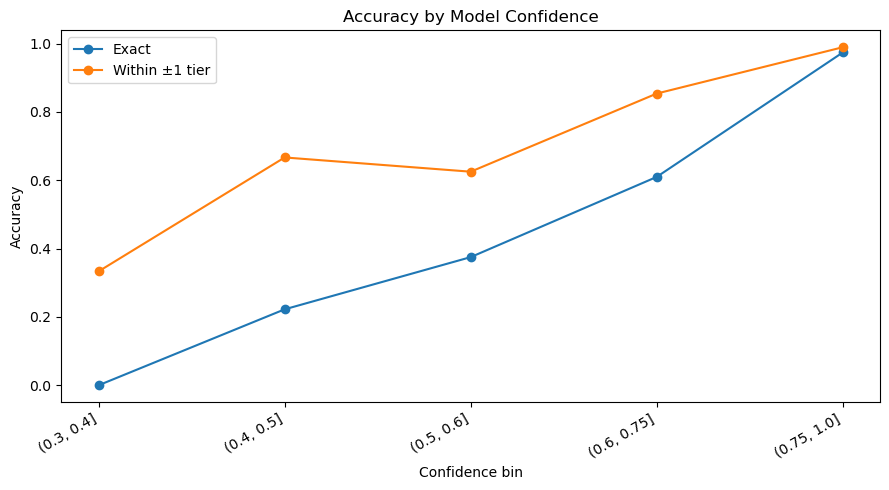

In [46]:
plt.figure(figsize=(9, 5))
x = np.arange(len(confidence_summary))
plt.plot(x, confidence_summary["exact_accuracy"], marker="o", label="Exact")
plt.plot(x, confidence_summary["within_1_tier"], marker="o", label="Within ±1 tier")
plt.xticks(x, confidence_summary.index.astype(str), rotation=30, ha="right")
plt.title("Accuracy by Model Confidence")
plt.xlabel("Confidence bin")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Part XVI — Information-set ablation

## 34. Final season vs. career average vs. combined NCAA statistics

Each compact feature set is trained on the same development period and evaluated on the same untouched 2022–2023 test cohort.

In [47]:
ablation_rows = []
for feature_set_name, cols in FEATURE_SETS.items():
    model = make_xgb(cols, **best_params)
    fit_with_balanced_weights(model, dev_df[cols], y_dev)
    proba = align_proba(model.predict_proba(test_df[cols]))
    pred = proba.argmax(axis=1)
    metrics = classification_metrics(y_test, pred, proba, feature_set_name)
    ablation_rows.append({
        "feature_set": feature_set_name,
        "n_features": len(cols),
        **metrics.to_dict(),
    })

ablation_table = pd.DataFrame(ablation_rows).set_index("feature_set")
ablation_table

,n_features,model,accuracy,balanced_accuracy,macro_f1,within_1_tier,class_mae,expected_tier_mae,qwk,log_loss
feature_set,,,,,,,,,,
final_season,38,final_season,0.933,0.304,0.306,0.969,0.108,0.143,0.454,0.258
career_average,38,career_average,0.932,0.221,0.215,0.972,0.107,0.130,0.392,0.243
combined,78,combined,0.936,0.296,0.301,0.971,0.105,0.120,0.451,0.226


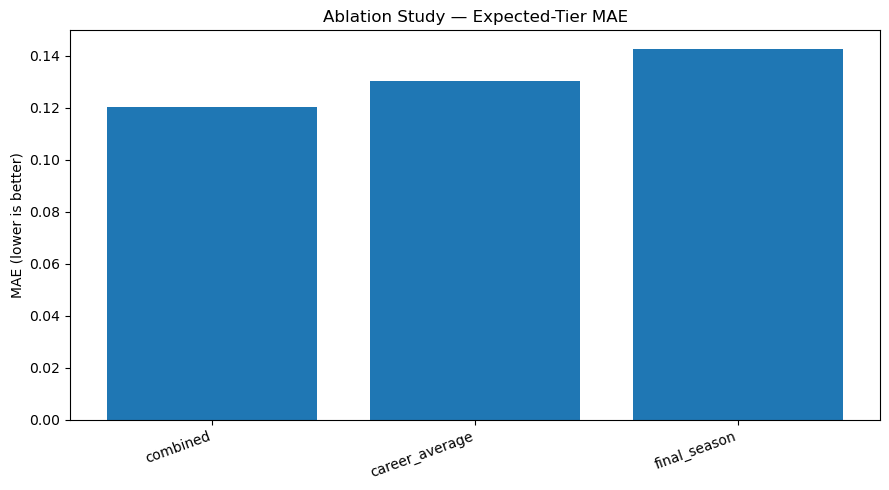

In [50]:
plt.figure(figsize=(9, 5))
ordered = ablation_table.sort_values("expected_tier_mae")
plt.bar(ordered.index, ordered["expected_tier_mae"])
plt.title("Ablation Study — Expected-Tier MAE")
plt.ylabel("MAE (lower is better)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Part XVII — Permutation importance

## 35. Which NCAA variables matter most?

Permutation importance measures how much test-set macro-F1 deteriorates when one input feature is randomly shuffled. It is model-specific and should be interpreted as predictive importance, not causality.

In [51]:
# Limit repeats for runtime; increase n_repeats for a more stable research run.
perm = permutation_importance(
    final_multiclass,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

importance_df = pd.DataFrame({
    "feature": full_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.head(30)

,feature,importance_mean,importance_std
4,career_mean_bpg,0.065,0.016
15,career_mean_fta,0.051,0.009
17,career_mean_gp,0.038,0.017
46,final_ediff,0.026,0.010
69,final_three_pct,0.022,0.014
59,final_ortg,0.017,0.009
29,career_mean_stl_pct,0.016,0.009
77,seasons_observed,0.015,0.021
11,career_mean_fga,0.015,0.011
39,final_apg,0.014,0.009


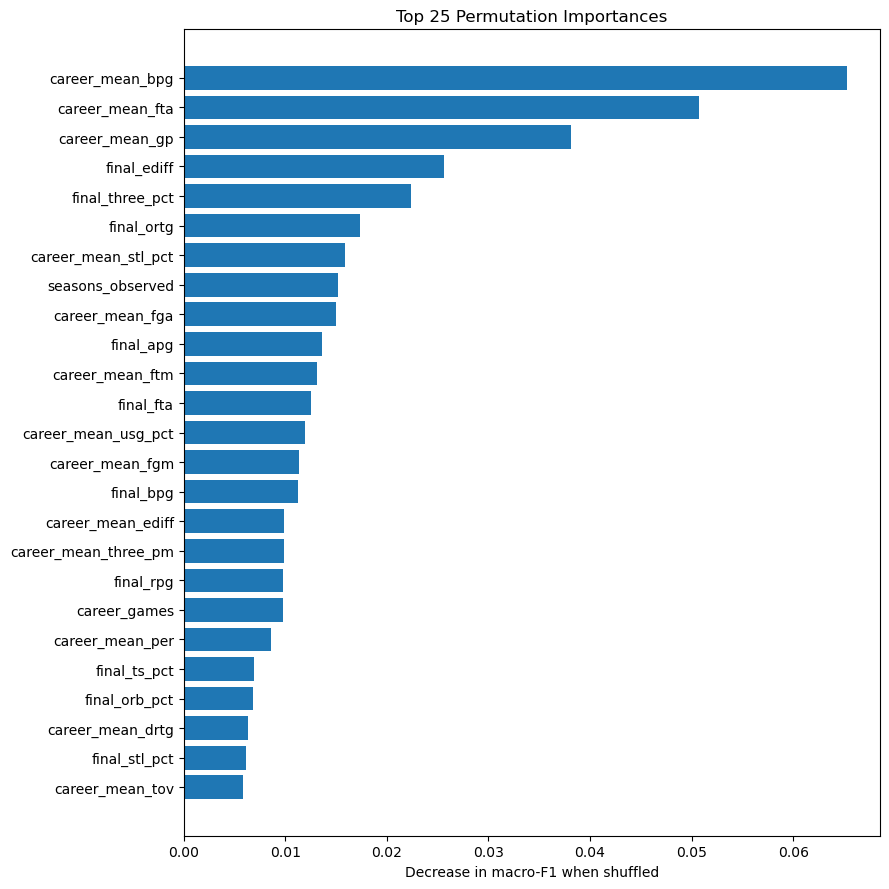

In [52]:
top_imp = importance_df.head(25).sort_values("importance_mean")
plt.figure(figsize=(9, 9))
plt.barh(top_imp["feature"], top_imp["importance_mean"])
plt.title("Top 25 Permutation Importances")
plt.xlabel("Decrease in macro-F1 when shuffled")
plt.tight_layout()
plt.show()

# Part XVIII — Basketball-specific error analysis

## 36. Performance by actual draft tier

In [53]:
error_by_tier = (
    results_test.groupby("draft_outcome")
    .agg(
        prospects=("player", "size"),
        exact_accuracy=("tier_distance", lambda x: (x == 0).mean()),
        within_1_tier=("tier_distance", lambda x: (x <= 1).mean()),
        mean_absolute_tier_error=("tier_distance", "mean"),
        mean_confidence=("confidence", "mean"),
    )
    .reindex(CLASS_NAMES)
)
error_by_tier

,prospects,exact_accuracy,within_1_tier,mean_absolute_tier_error,mean_confidence
draft_outcome,,,,,
Top 5,6,0.167,0.667,1.167,0.568
Lottery (6-14),10,0.100,0.100,2.300,0.691
Rest of 1st (15-30),16,0.062,0.125,1.812,0.726
2nd Round,23,0.174,0.957,0.870,0.757
Undrafted,1144,0.975,0.992,0.041,0.965


## 37. Performance by test draft year

In [54]:
year_error = (
    results_test.groupby("anchor_year")
    .agg(
        prospects=("player", "size"),
        exact_accuracy=("tier_distance", lambda x: (x == 0).mean()),
        within_1_tier=("tier_distance", lambda x: (x <= 1).mean()),
        mean_absolute_tier_error=("tier_distance", "mean"),
        mean_confidence=("confidence", "mean"),
    )
)
year_error

,prospects,exact_accuracy,within_1_tier,mean_absolute_tier_error,mean_confidence
anchor_year,,,,,
2022,558,0.935,0.970,0.106,0.953
2023,641,0.936,0.972,0.105,0.954


# Part XIX — Expanding-window stability

## 38. Evaluate the tuned model across multiple historical holdout years

A single test period can be unusually easy or difficult. Expanding-window evaluation measures whether performance is reasonably stable across draft eras.

In [55]:
stability_years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
stability_rows = []

for holdout_year in stability_years:
    tr = model_df[model_df["anchor_year"] < holdout_year]
    va = model_df[model_df["anchor_year"] == holdout_year]
    if tr.empty or va.empty:
        continue

    model = make_xgb(full_cols, **best_params)
    fit_with_balanced_weights(model, tr[full_cols], tr["target"].astype(int))
    proba = align_proba(model.predict_proba(va[full_cols]))
    pred = proba.argmax(axis=1)
    m = classification_metrics(va["target"].astype(int), pred, proba, str(holdout_year))
    stability_rows.append({"year": holdout_year, "n": len(va), **m.to_dict()})

stability_df = pd.DataFrame(stability_rows).set_index("year")
stability_df

,n,model,accuracy,balanced_accuracy,macro_f1,within_1_tier,class_mae,expected_tier_mae,qwk,log_loss
year,,,,,,,,,,
2016,528,2016,0.920,0.357,0.325,0.962,0.140,0.145,0.483,0.292
2017,528,2017,0.924,0.409,0.413,0.972,0.123,0.132,0.577,0.271
2018,510,2018,0.933,0.382,0.370,0.971,0.118,0.142,0.406,0.291
2019,554,2019,0.919,0.438,0.455,0.971,0.119,0.148,0.577,0.307
2020,540,2020,0.924,0.277,0.290,0.978,0.113,0.120,0.416,0.329
2021,440,2021,0.920,0.198,0.193,0.973,0.118,0.124,0.260,0.391
2022,558,2022,0.932,0.337,0.345,0.973,0.104,0.117,0.638,0.226
2023,641,2023,0.936,0.241,0.234,0.972,0.103,0.125,0.235,0.240


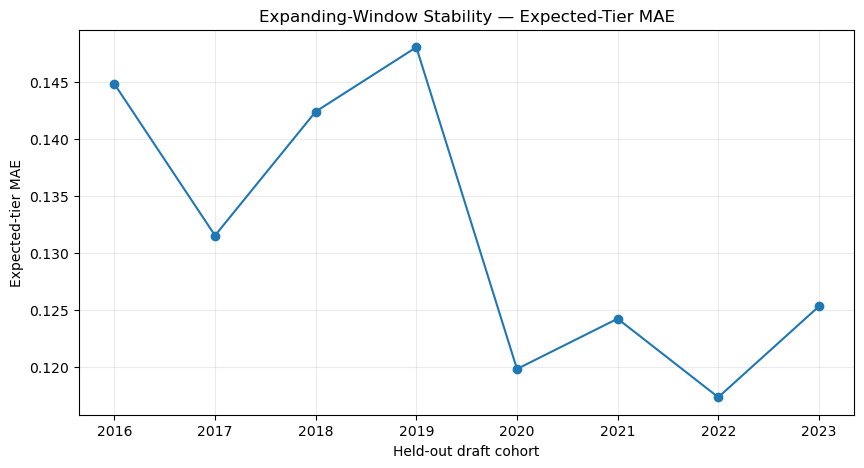

In [56]:
plt.figure(figsize=(10, 5))
plt.plot(stability_df.index, stability_df["expected_tier_mae"], marker="o")
plt.title("Expanding-Window Stability — Expected-Tier MAE")
plt.xlabel("Held-out draft cohort")
plt.ylabel("Expected-tier MAE")
plt.grid(alpha=0.25)
plt.show()

# Part XX — Export reusable artifacts

## 39. Save the final models, metadata, and predictions

In [57]:
ARTIFACT_DIR = Path("nba_draft_tier_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(final_multiclass, ARTIFACT_DIR / "nba_draft_tier_multiclass_xgb.joblib")
joblib.dump(final_ordinal_preprocess, ARTIFACT_DIR / "nba_draft_tier_ordinal_preprocessor.joblib")
joblib.dump(final_ordinal, ARTIFACT_DIR / "nba_draft_tier_ordinal_xgb.joblib")

metadata = {
    "class_names": CLASS_NAMES,
    "feature_columns": full_cols,
    "best_params": best_params,
    "blend_weight_multiclass": BEST_BLEND_WEIGHT,
    "training_year_max": int(dev_df["anchor_year"].max()),
    "test_years": TEST_YEARS,
    "minimum_career_games": MIN_CAREER_GAMES,
}
joblib.dump(metadata, ARTIFACT_DIR / "nba_draft_tier_metadata.joblib")

results_test.sort_values(["anchor_year", "expected_tier"]).to_csv(
    ARTIFACT_DIR / "nba_draft_tier_test_predictions.csv", index=False
)

print("Saved artifacts to:", ARTIFACT_DIR.resolve())

Saved artifacts to: /Users/svlahos/Downloads/nba_draft_tier_artifacts


# 40. Interpretation checklist

After running the notebook, use the outputs to answer more than "what was the accuracy?"

### Predictive performance
- How often is the exact tier correct?
- How often is the prediction within one tier?
- How large is expected-tier MAE?
- Does the ordered model reduce severe misses relative to ordinary multiclass XGBoost?

### Information value
- How much signal is contained in the final NCAA season?
- Do career-average statistics improve out-of-time prediction?
- Does combining traditional and advanced production provide a meaningful lift?
- Which original NCAA statistics carry the most predictive signal?

### Basketball interpretation
- Which statistical profiles are consistently associated with earlier draft tiers?
- Which prospects were drafted much earlier than their NCAA-statistical profile implied?
- Which productive college players were selected later than the model expected?

### Model quality
- Does confidence correspond to actual accuracy?
- Is performance stable across draft years?
- Are most errors adjacent-tier errors rather than extreme misses?

# 41. Limitations

This project intentionally uses only the supplied public statistical data. Important omitted variables include:

- age and date of birth,
- height, weight, wingspan, and standing reach,
- combine/pro-day athletic testing,
- position and role labels,
- school/team strength and conference quality,
- play-by-play and tracking data,
- shot-location and shot-quality information,
- on/off and lineup context,
- injuries and medical evaluations,
- film/scouting grades,
- interviews and psychological assessments,
- international statistics for non-NCAA prospects,
- team needs, trades, and front-office preferences.

There are also source-specific limitations:

1. **No shared player ID.** Name matching can still fail or collide despite temporal safeguards.
2. **Undrafted status is inferred.** The draft file does not explicitly list undrafted players, so the final observed NCAA cohort is used as the negative pool.
3. **NCAA source coverage differs.** Traditional and advanced tables do not contain identical player-season coverage; missing values are therefore meaningful and handled inside the modeling pipeline.
4. **Draft position is round-relative.** The source resets pick numbers in Round 2, so target construction uses the round label explicitly.

These are not reasons to discard the project; they are part of the data-engineering problem and should be stated clearly when presenting results.

# 42. Portfolio summary

**Project:** NBA Draft Tier Prediction from NCAA Statistics

**Problem:** Predict whether an NCAA player will be a Top-5 pick, Lottery pick, later first-round pick, second-round pick, or go undrafted.

**Technical highlights:**

- integrated 15K+ traditional and advanced NCAA player-season records with historical NBA draft outcomes,
- built conservative player-name entity resolution and temporal matching without shared IDs,
- inferred an undrafted comparison cohort,
- kept feature engineering compact with final-season and career-average versions of the supplied NCAA statistics,
- used leakage-aware chronological validation,
- compared linear, random-forest, multiclass boosting, and custom ordinal boosting models,
- tuned XGBoost with Optuna TPE Bayesian optimization,
- blended multiclass and ordinal probability forecasts,
- evaluated uncertainty, tier-specific errors, temporal stability, and feature-set ablations,
- exported reusable models and prospect-level test predictions.

A concise interview description:

> **I built an end-to-end NBA draft model that converts NCAA traditional and advanced statistics into ordered draft-tier probabilities. I kept the feature set close to the source data, used chronological validation, built a cumulative ordinal XGBoost model, tuned it with Bayesian optimization, and combined it with multiclass boosting to produce interpretable prospect-level probabilities and uncertainty diagnostics.**